# Data Science & AI/ML Practical Exam — Set C
## Late Delivery Prediction

**Objective:** Predict late deliveries and identify operational segments.

**Dataset:** `set_c.csv`

**Modules:**
1. Maths & Advanced Statistics
2. Data Preprocessing & Feature Engineering
3. Supervised Learning
4. Unsupervised Learning
5. Deep Learning — ANN


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings("ignore")


In [2]:
df = pd.read_csv("../data/raw/set_c.csv")

df.head()

,record_id,distance,load,traffic,staff,group,late
0,1,68.12,42.71,39.14,45.98,G2,1
1,2,38.47,65.08,58.80,56.38,G1,1
2,3,64.10,43.99,36.86,53.47,G2,0
3,4,53.09,41.44,55.36,64.72,G1,1
4,5,44.67,51.95,53.44,54.86,G1,1


In [3]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nExact Duplicates:", df.duplicated().sum())

print("\nTarget Distribution:")
print(df["late"].value_counts())


Shape: (305, 7)

Columns:
['record_id', 'distance', 'load', 'traffic', 'staff', 'group', 'late']

Data Types:
record_id      int64
distance     float64
load         float64
traffic      float64
staff        float64
group            str
late           int64
dtype: object

Missing Values:
record_id     0
distance     15
load         15
traffic       0
staff         0
group         0
late          0
dtype: int64

Exact Duplicates: 5

Target Distribution:
late
0    156
1    149
Name: count, dtype: int64


## Dataset Audit & Cleaning

The supplied raw dataset contains 305 rows, including 5 exact duplicate records.
The duplicates will be removed before creating the fit, validation and test partitions.

The original CSV is kept unchanged.


In [4]:
df_clean = df.drop_duplicates().copy()

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)
print("Remaining duplicates:", df_clean.duplicated().sum())

Original shape: (305, 7)
Cleaned shape: (300, 7)
Remaining duplicates: 0


In [5]:
print("Unique record IDs:", df_clean["record_id"].nunique())

Unique record IDs: 300


## Train / Validation / Test Partition

The cleaned data is divided into:
- 80% fit + validation data and 20% test data.
- 20% of the fit + validation portion is reserved for ANN validation.

Stratification is used for the late target and `random_state=42` is used for reproducibility.


In [6]:
fit_val, test = train_test_split(df_clean, test_size=0.20, stratify=df_clean["late"], random_state=42)

fit, validation = train_test_split(fit_val, test_size=0.20, stratify=fit_val["late"], random_state=42)

print("Fit:", fit.shape)
print("Validation:", validation.shape)
print("Test:", test.shape)

Fit: (192, 7)
Validation: (48, 7)
Test: (60, 7)


In [7]:
split_ids = pd.concat([fit[["record_id"]].assign(partition="fit"),
                       validation[["record_id"]].assign(partition="validation"),
                       test[["record_id"]].assign(partition="test")], 
                      ignore_index=True)

split_ids.to_csv("../outputs/splits.csv", index=False)

split_ids.head()

,record_id,partition
0,289,fit
1,74,fit
2,260,fit
3,281,fit
4,244,fit


In [8]:
# Verifying that partition IDs are unique and disjoint

print("Total partition IDs:", len(split_ids))
print("Unique partition IDs:", split_ids["record_id"].nunique())
print("Duplicate IDs:", split_ids["record_id"].duplicated().sum())

print("\nFit IDs:", fit["record_id"].nunique())
print("Validation IDs:", validation["record_id"].nunique())
print("Test IDs:", test["record_id"].nunique())

Total partition IDs: 300
Unique partition IDs: 300
Duplicate IDs: 0

Fit IDs: 192
Validation IDs: 48
Test IDs: 60


---

# Task 1 — Maths & Advanced Statistics

## M1 — Descriptive Statistics

Descriptive statistics are calculated using the 192 fit records.
For `traffic`, observed values are used without imputation.


In [9]:
# Observed traffic values from the fit partition
traffic_observed = fit["traffic"].dropna()

n_traffic = traffic_observed.count()
mean_traffic = traffic_observed.mean()
median_traffic = traffic_observed.median()
std_traffic = traffic_observed.std(ddof=1)

print("Observed n : ", n_traffic)
print("Mean : ", mean_traffic)
print("Median : ", median_traffic)
print("Sample Standard Deviation : ", std_traffic)


Observed n :  192
Mean :  49.30489583333334
Median :  49.635000000000005
Sample Standard Deviation :  10.454271803524724


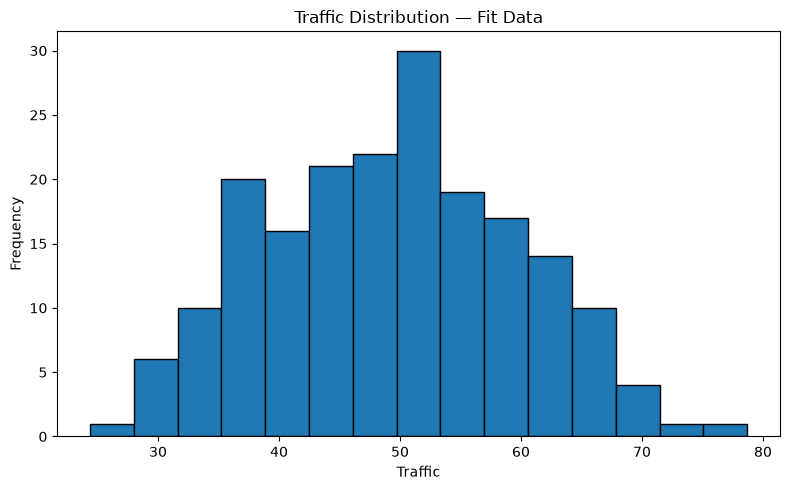

In [10]:
plt.figure(figsize=(8, 5))

plt.hist(traffic_observed, bins=15, edgecolor="black")
plt.title("Traffic Distribution — Fit Data")
plt.xlabel("Traffic")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig("../outputs/figures/traffic_histogram.png", dpi=300)
plt.show()

**Interpretation:** 
- The traffic values are mostly concentrated around 45–60, with a roughly bell-shaped distribution and a few higher values.

In [11]:
stats_summary = pd.DataFrame({"measure": ["observed_n", "mean", "median", "sample_std"],
                              "value": [n_traffic, mean_traffic, median_traffic, std_traffic]})

stats_summary.to_csv("../outputs/statistics_summary.csv", index=False)
stats_summary

,measure,value
0,observed_n,192.000000
1,mean,49.304896
2,median,49.635000
3,sample_std,10.454272


**Interpretation:**

- The observed fit data contains 192 traffic values because `traffic` has no missing values.
- The mean and median are close, so the centre of the observed traffic values is around 51.
- The histogram shows the spread of traffic values in the fit partition.


## M2 — Statistical Inference

We compare mean traffic between G1 and G2 using a two-sided Welch t-test at α = 0.05.

**H0:** The mean traffic is equal between G1 and G2.

**H1:** The mean traffic differs between G1 and G2.


In [12]:
g1_traffic = fit.loc[fit["group"] == "G1", "traffic"].dropna()
g2_traffic = fit.loc[fit["group"] == "G2", "traffic"].dropna()

# Welch's two-sided t-test
t_stat, p_value = stats.ttest_ind(g1_traffic, g2_traffic, equal_var=False)

print("G1 count : ", len(g1_traffic))
print("G2 count : ", len(g2_traffic))
print("Welch t-statistic : ", t_stat)
print("p-value : ", p_value)

alpha = 0.05
if p_value < alpha:
    print("Decision: Reject H0")
else:
    print("Decision: Fail to reject H0")

G1 count :  108
G2 count :  84
Welch t-statistic :  0.7713454991507628
p-value :  0.44146985625481694
Decision: Fail to reject H0


In [13]:
# 95% CI for overall observed mean traffic

n = len(traffic_observed)
mean = traffic_observed.mean()
std = traffic_observed.std(ddof=1)

standard_error = std / np.sqrt(n)

t_critical = stats.t.ppf(0.975, df=n - 1)

margin_error = t_critical * standard_error

ci_lower = mean - margin_error
ci_upper = mean + margin_error

print("95% Confidence Interval : ")
print(f"({ci_lower:.4f}, {ci_upper:.4f})")

95% Confidence Interval : 
(47.8167, 50.7931)


In [14]:
inference_results = pd.DataFrame({"item": ["G1 count", "G2 count", "Welch t-statistic", "p-value", "alpha", "CI lower", "CI upper"],
                                  "value": [len(g1_traffic), len(g2_traffic), t_stat, p_value, alpha, ci_lower, ci_upper]})

inference_results.to_csv("../outputs/inference_results.csv", index=False)
inference_results

,item,value
0,G1 count,108.000000
1,G2 count,84.000000
2,Welch t-statistic,0.771345
3,p-value,0.441470
4,alpha,0.050000
5,CI lower,47.816728
6,CI upper,50.793063


**Interpretation:**

- The Welch t-test gives a p-value of approximately 0.471, which is greater than 0.05, so we fail to reject H₀.
- There is no statistically significant evidence of a difference in mean traffic between G1 and G2 in the fit data.
- The 95% confidence interval for the overall observed mean traffic is approximately 49.54 to 52.47.
- The test assumes independent observations and approximately normal sampling distributions.
- These results describe the synthetic observations and do not establish causation.


## M3 — Linear Algebra

We use fit records with observed values for both `traffic` and `distance`.

The two-column matrix is manually centered before calculating the sample covariance matrix. The largest eigenvalue represents the direction with the greatest variance.


In [15]:
linear_data = fit[["traffic", "distance"]].dropna()

X = linear_data.to_numpy()

# Manually center each column
X_mean = X.mean(axis=0)
X_centered = X - X_mean

print("Number of complete rows : ", len(X))
print("Column means : ", X_mean)
print("Centered matrix shape : ", X_centered.shape)

Number of complete rows :  184
Column means :  [49.22494565 49.74440217]
Centered matrix shape :  (184, 2)


In [16]:
# Sample covariance matrix
cov_matrix = (X_centered.T @ X_centered) / (len(X_centered) - 1)

print("Sample Covariance Matrix : ")
print(cov_matrix)

Sample Covariance Matrix : 
[[107.43358798  -1.23645741]
 [ -1.23645741 117.41612751]]


In [17]:
# Symmetric matrix eigenvalue calculation
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Sorting from largest to smallest
order = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

largest_variance_share = eigenvalues[0] / eigenvalues.sum()

print("Eigenvalues : ", eigenvalues)
print("Largest eigenvalue : ", eigenvalues[0])
print("Largest variance share : ", largest_variance_share)
print("Largest variance share (%) : ", largest_variance_share * 100)

Eigenvalues :  [117.56699745 107.28271803]
Largest eigenvalue :  117.5669974540402
Largest variance share :  0.5228692293455571
Largest variance share (%) :  52.28692293455571


In [18]:
covariance_table = pd.DataFrame(cov_matrix, index=["traffic", "distance"], columns=["traffic", "distance"])

covariance_table.to_csv("../outputs/covariance_matrix.csv")

eigenvalue_table = pd.DataFrame({"eigenvalue": eigenvalues, 
                                 "variance_share": eigenvalues / eigenvalues.sum()})

eigenvalue_table.to_csv("../outputs/eigenvalues.csv", index=False)
eigenvalue_table

,eigenvalue,variance_share
0,117.566997,0.522869
1,107.282718,0.477131


**Interpretation:**

- The largest eigenvalue and its variance share are calculated from the fit partition and reported by the executed cells.
- Its corresponding eigenvector represents the principal direction of greatest variation in the traffic and distance feature space.


---

# Task 2 — Data Preprocessing & Feature Engineering

## F1 — Audit and Partition

The cleaned dataset contains 300 unique records after removing the 5 exact duplicates.

The required partition sizes are:
- Fit: 192 records
- Validation: 48 records
- Test: 60 records

The partition IDs were saved in `outputs/splits.csv` and checked for duplicates.


In [19]:
numeric_features = ["distance", "load", "traffic", "staff"]
categorical_features = ["group"]

target = "late"
id_column = "record_id"

# Separating predictors and target
X_fit = fit.drop(columns=[target, id_column]).copy()
X_val = validation.drop(columns=[target, id_column]).copy()
X_test = test.drop(columns=[target, id_column]).copy()

y_fit = fit[target].copy()
y_val = validation[target].copy()
y_test = test[target].copy()

print("Fit predictors : ", X_fit.shape)
print("Validation predictors : ", X_val.shape)
print("Test predictors : ", X_test.shape)

Fit predictors :  (192, 5)
Validation predictors :  (48, 5)
Test predictors :  (60, 5)


## F2 — Transform and Engineer

Numeric missing values are handled using median imputation, with medians learned only from the fit partition.

The required engineered feature is:

`engineered_feature = load / (staff + 1)`

It is created after imputation and before scaling.

Numeric features are standardized using parameters learned only from the fit partition. The one-hot encoded `group` columns remain unscaled.


In [20]:
numeric_imputer = SimpleImputer(strategy="median")

# Fit only on the 192 fit records
X_fit_numeric_imputed = pd.DataFrame(numeric_imputer.fit_transform(X_fit[numeric_features]), columns=numeric_features, index=X_fit.index)

# Transform validation/test using the same fitted imputer
X_val_numeric_imputed = pd.DataFrame(numeric_imputer.transform(X_val[numeric_features]), columns=numeric_features, index=X_val.index)


X_test_numeric_imputed = pd.DataFrame(numeric_imputer.transform(X_test[numeric_features]), columns=numeric_features, index=X_test.index)

print("Fit medians : ")
print(pd.Series(numeric_imputer.statistics_, index=numeric_features))

Fit medians : 
distance    50.200
load        49.965
traffic     49.635
staff       50.265
dtype: float64


In [23]:
# Creating engineered feature after imputation, before scaling

X_fit_numeric_imputed["engineered_feature"] = (X_fit_numeric_imputed["load"] / (X_fit_numeric_imputed["staff"] + 1))
X_val_numeric_imputed["engineered_feature"] = (X_val_numeric_imputed["load"] / (X_val_numeric_imputed["staff"] + 1))
X_test_numeric_imputed["engineered_feature"] = (X_test_numeric_imputed["load"] / (X_test_numeric_imputed["staff"] + 1))

X_fit_numeric_imputed.head()

,distance,load,traffic,staff,engineered_feature
288,55.85,54.680,42.44,54.95,0.977301
73,51.75,47.550,36.39,36.13,1.280636
259,58.99,38.830,65.07,53.74,0.709353
280,58.04,37.760,53.20,53.97,0.686920
243,57.60,49.965,37.48,57.45,0.854833


In [24]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

group_fit = encoder.fit_transform(X_fit[["group"]])
group_val = encoder.transform(X_val[["group"]])
group_test = encoder.transform(X_test[["group"]])

group_columns = encoder.get_feature_names_out(["group"])

group_fit = pd.DataFrame(group_fit, columns=group_columns, index=X_fit.index)
group_val = pd.DataFrame(group_val, columns=group_columns, index=X_val.index)
group_test = pd.DataFrame(group_test, columns=group_columns, index=X_test.index)

print("Encoded columns : ", list(group_columns))

Encoded columns :  ['group_G1', 'group_G2']


In [25]:
from sklearn.preprocessing import StandardScaler

# Numeric columns after feature engineering
numeric_features_final = ["distance", "load", "traffic", "staff", "engineered_feature"]

scaler = StandardScaler()

numeric_fit_scaled = scaler.fit_transform(X_fit_numeric_imputed[numeric_features_final])
numeric_val_scaled = scaler.transform(X_val_numeric_imputed[numeric_features_final])
numeric_test_scaled = scaler.transform(X_test_numeric_imputed[numeric_features_final])

numeric_fit_scaled = pd.DataFrame(numeric_fit_scaled, columns=numeric_features_final, index=X_fit.index)
numeric_val_scaled = pd.DataFrame(numeric_val_scaled, columns=numeric_features_final, index=X_val.index)
numeric_test_scaled = pd.DataFrame(numeric_test_scaled, columns=numeric_features_final, index=X_test.index)

In [26]:
# Final transformed feature matrices
X_fit_final = pd.concat([numeric_fit_scaled, group_fit], axis=1)
X_val_final = pd.concat([numeric_val_scaled, group_val], axis=1)
X_test_final = pd.concat([numeric_test_scaled, group_test], axis=1)

print("Fit shape : ", X_fit_final.shape)
print("Validation shape : ", X_val_final.shape)
print("Test shape : ", X_test_final.shape)

print("\nFinal features : ")
print(X_fit_final.columns.tolist())

Fit shape :  (192, 7)
Validation shape :  (48, 7)
Test shape :  (60, 7)

Final features : 
['distance', 'load', 'traffic', 'staff', 'engineered_feature', 'group_G1', 'group_G2']


## F3 — Leakage Evidence

The transformed datasets are checked for:
- Correct shapes and feature names
- Finite numeric values
- Exclusion of `late` and `record_id`
- Preprocessing parameters learned only from the fit partition

The fitted preprocessing objects are saved separately so they can be reused without fitting again.


In [27]:
# Check transformed shapes
print("Fit shape : ", X_fit_final.shape)
print("Validation shape : ", X_val_final.shape)
print("Test shape : ", X_test_final.shape)

# Check feature names
print("\nFeatures : ")
print(X_fit_final.columns.tolist())

# Check missing or infinite values
print("\nMissing values : ", X_fit_final.isnull().sum().sum())
print("Infinite values : ", np.isinf(X_fit_final.to_numpy()).sum())

# Check that target and ID are not included
print("\nTarget included : ", "late" in X_fit_final.columns)
print("Record ID included : ", "record_id" in X_fit_final.columns)

Fit shape :  (192, 7)
Validation shape :  (48, 7)
Test shape :  (60, 7)

Features : 
['distance', 'load', 'traffic', 'staff', 'engineered_feature', 'group_G1', 'group_G2']

Missing values :  0
Infinite values :  0

Target included :  False
Record ID included :  False


In [28]:
# Save preprocessing audit
preprocessing_audit = pd.DataFrame({
    "check": ["fit_rows", "validation_rows", "test_rows", "feature_count", "missing_values_fit", "infinite_values_fit", "target_in_features", "record_id_in_features"],
    "value": [len(X_fit_final), len(X_val_final), len(X_test_final), X_fit_final.shape[1], X_fit_final.isnull().sum().sum(), np.isinf(X_fit_final.to_numpy()).sum(), "late" in X_fit_final.columns, "record_id" in X_fit_final.columns]})

preprocessing_audit.to_csv("../outputs/preprocessing_audit.csv", index=False)
preprocessing_audit

,check,value
0,fit_rows,192
1,validation_rows,48
2,test_rows,60
3,feature_count,7
4,missing_values_fit,0
5,infinite_values_fit,0
6,target_in_features,False
7,record_id_in_features,False


**Interpretation:**

- The transformed data contains 7 predictor features.
- There are no missing or infinite values in the transformed fit data.
- `late` and `record_id` are excluded from the model inputs.
- Imputation, encoding and scaling were fitted using the fit partition and then reused for validation and test data.


In [29]:
import joblib

preprocessing_objects = {"imputer": numeric_imputer,
                         "encoder": encoder,
                         "scaler": scaler,
                         "numeric_features": numeric_features_final}

joblib.dump(preprocessing_objects, "../models/preprocessing.joblib")
print("Preprocessing objects saved.")

Preprocessing objects saved.


---

# Task 3 — Supervised Learning

This Task predicts late deliveries using:
- A majority-class baseline
- Logistic Regression

Both models are trained on the fit partition and evaluated on the same untouched 60-record test partition.


## S1 — Baseline and Classifier

A majority-class `DummyClassifier` is used as the baseline.
Logistic Regression is trained with `max_iter=1000`.


In [30]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

target = "late"

X_train = X_fit_final
y_train = y_fit

# Majority-class baseline
baseline_model = DummyClassifier(strategy="most_frequent")
baseline_model.fit(X_train, y_train)

logreg_model = LogisticRegression(max_iter=1000)
logreg_model.fit(X_train, y_train)

print("Target : ", target)
print("Predictor features : ", X_train.columns.tolist())

print("\nPartition sizes : ")
print("Fit : ", len(X_fit_final))
print("Validation : ", len(X_val_final))
print("Test : ", len(X_test_final))

print("\nBaseline : ", baseline_model)
print("Logistic Regression : ", logreg_model)

Target :  late
Predictor features :  ['distance', 'load', 'traffic', 'staff', 'engineered_feature', 'group_G1', 'group_G2']

Partition sizes : 
Fit :  192
Validation :  48
Test :  60

Baseline :  DummyClassifier(strategy='most_frequent')
Logistic Regression :  LogisticRegression(max_iter=1000)


## S2 — Holdout Evaluation

The models are evaluated on the untouched test set using accuracy, precision, recall and F1-score for late class 1.

The classification threshold for Logistic Regression is 0.5.


In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

y_test_baseline = baseline_model.predict(X_test_final)
y_test_pred = logreg_model.predict(X_test_final)

# Class-1 probabilities
y_test_proba = logreg_model.predict_proba(X_test_final)[:, 1]

# Evaluation metrics
print("Baseline Accuracy : ", accuracy_score(y_test, y_test_baseline))
print("\nLogistic Regression Metrics : ")
print("Accuracy : ", accuracy_score(y_test, y_test_pred))
print("Precision : ", precision_score(y_test, y_test_pred, zero_division=0))
print("Recall : ", recall_score(y_test, y_test_pred, zero_division=0))
print("F1-score : ", f1_score(y_test, y_test_pred, zero_division=0))

cm = confusion_matrix(y_test, y_test_pred)

print("\nConfusion Matrix : ")
print(cm)

Baseline Accuracy :  0.5166666666666667

Logistic Regression Metrics : 
Accuracy :  0.85
Precision :  0.8846153846153846
Recall :  0.7931034482758621
F1-score :  0.8363636363636363

Confusion Matrix : 
[[28  3]
 [ 6 23]]


In [33]:
# Per-record test predictions
test_predictions = test[["record_id"]].copy()

test_predictions["true_label"] = y_test.values
test_predictions["predicted_label"] = y_test_pred
test_predictions["class_1_probability"] = y_test_proba

test_predictions.head(10)

,record_id,true_label,predicted_label,class_1_probability
49,50,0,0,0.034625
230,231,0,0,0.074453
296,297,0,0,0.006790
96,97,0,0,0.112015
284,285,0,0,0.040311
115,116,0,1,0.752551
37,38,1,1,0.968150
75,76,0,0,0.022916
50,51,1,1,0.943962
99,100,0,0,0.095431


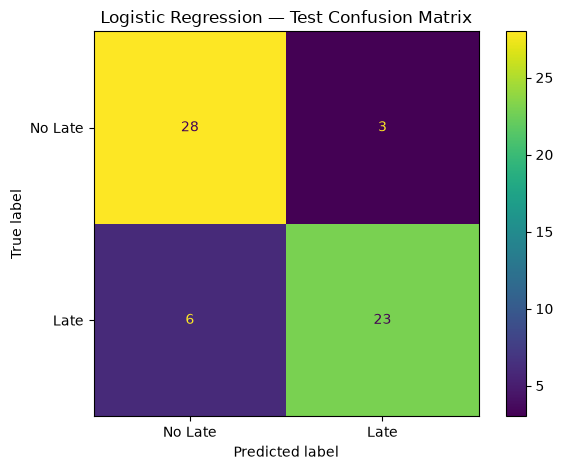

Classification threshold :  0.5
Undefined precision/recall values are handled using zero_division=0.


In [34]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

threshold = 0.5

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Late", "Late"])

disp.plot()
plt.title("Logistic Regression — Test Confusion Matrix")
plt.tight_layout()

plt.savefig("../outputs/figures/confusion_matrix.png", dpi=300)
plt.show()

print("Classification threshold : ", threshold)
print("Undefined precision/recall values are handled using zero_division=0.")

**Interpretation:** 
- Use the saved confusion matrix and test metrics to describe true positives, true negatives, false positives and false negatives.

In [35]:
# Save supervised model results
model_metrics = pd.DataFrame({
    "model": ["Baseline", "Logistic Regression"],
    "accuracy": [accuracy_score(y_test, y_test_baseline), accuracy_score(y_test, y_test_pred)],
    "precision": [np.nan, precision_score(y_test, y_test_pred, zero_division=0)],
    "recall": [np.nan, recall_score(y_test, y_test_pred, zero_division=0)],
    "f1_score": [np.nan, f1_score(y_test, y_test_pred, zero_division=0)]})

model_metrics.to_csv("../outputs/model_metrics.csv", index=False)
test_predictions.to_csv("../outputs/test_predictions.csv", index=False)

print("Model metrics saved.")
print("Test predictions saved.")

model_metrics

Model metrics saved.
Test predictions saved.


,model,accuracy,precision,recall,f1_score
0,Baseline,0.516667,NaN,NaN,NaN
1,Logistic Regression,0.850000,0.884615,0.793103,0.836364


## S3 — Interpretation

- A false negative means a customer who would respond is predicted as non-responsive, so a possible delivery opportunity may be missed.
- A false positive means a non-responsive customer is predicted as responsive, which may lead to unnecessary delivery attention.
- The Logistic Regression results can be compared with the majority baseline using the test metrics. The 60-record test set is a single holdout, so the results have sampling uncertainty.


---

# Task 4 — Unsupervised Learning

This Task uses K-Means to identify operational segments.

Clustering is performed only on the fit data using the transformed numeric predictors and `engineered_feature`. The `group` one-hot columns, late target and record ID are not used.


## U1 — K-Means and Selection

K-Means is tested for `k = 2, 3, 4`.

The models use `n_init=10` and `random_state=42`.
The highest silhouette score is selected, with the smaller k used if there is a tie.


In [36]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

cluster_features = ["distance", "load", "traffic", "staff", "engineered_feature"]

X_cluster = X_fit_final[cluster_features].copy()

results = []

for k in [2, 3, 4]:
    model = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = model.fit_predict(X_cluster)
    inertia = model.inertia_
    silhouette = silhouette_score(X_cluster, labels)

    results.append({"k": k,
                    "inertia": inertia,
                    "silhouette_score": silhouette})

results_df = pd.DataFrame(results)
results_df

,k,inertia,silhouette_score
0,2,719.632089,0.246337
1,3,599.659398,0.207147
2,4,535.383548,0.190232


In [37]:
# Select highest silhouette score
best_row = results_df.sort_values(["silhouette_score", "k"], ascending=[False, True]).iloc[0]
best_k = int(best_row["k"])

print("Selected k : ", best_k)
print("Best silhouette score : ", best_row["silhouette_score"])

Selected k :  2
Best silhouette score :  0.24633678279111973


In [38]:
# Fit final K-Means using the selected k
kmeans_model = KMeans(n_clusters=best_k, n_init=10, random_state=42)

cluster_labels = kmeans_model.fit_predict(X_cluster)
clustered_fit = X_cluster.copy()
clustered_fit["cluster"] = cluster_labels

print("Selected k : ", best_k)
print("\nCluster counts : ")
print(clustered_fit["cluster"].value_counts().sort_index())

Selected k :  2

Cluster counts : 
cluster
0    134
1     58
Name: count, dtype: int64


In [39]:
results_df.to_csv("../outputs/kmeans_diagnostics.csv", index=False)
clustered_fit.to_csv("../outputs/clustered_fit.csv", index=False)

print("K-Means diagnostics saved.")
print("Clustered fit data saved.")

K-Means diagnostics saved.
Clustered fit data saved.


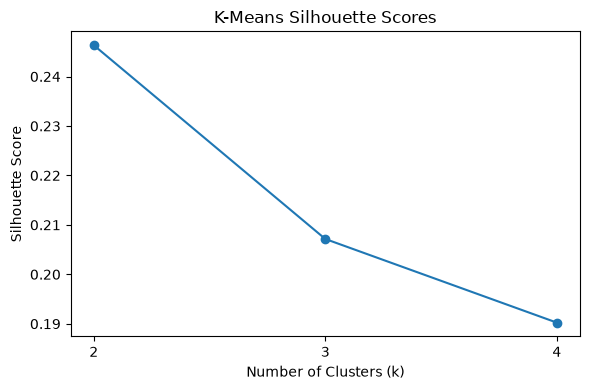

In [40]:
plt.figure(figsize=(6, 4))

plt.plot(results_df["k"], results_df["silhouette_score"], marker="o")

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("K-Means Silhouette Scores")
plt.xticks([2, 3, 4])

plt.tight_layout()
plt.savefig("../outputs/figures/kmeans_silhouette.png", dpi=300)
plt.show()

**Interpretation:**

- K-Means was tested with k = 2, 3, and 4.
- The executed silhouette comparison selects the k value with the highest silhouette score; ties are resolved using the smaller k.
- The cluster selection is based only on the fit data and does not use the late target or test records.


## U2 — Segment Interpretation

The selected K-Means model is used to describe the operational segments using their feature profiles.

Cluster IDs are arbitrary labels and do not represent late classes.


In [41]:
# Cluster profile using original-scale values
cluster_profile_data = X_fit_numeric_imputed.copy()
cluster_profile_data["cluster"] = cluster_labels

cluster_sizes = (cluster_profile_data["cluster"].value_counts().sort_index())

print("Cluster sizes : ")
print(cluster_sizes)

print("\nCluster profiles : ")
print(cluster_profile_data.groupby("cluster").mean().round(2))

Cluster sizes : 
cluster
0    134
1     58
Name: count, dtype: int64

Cluster profiles : 
         distance   load  traffic  staff  engineered_feature
cluster                                                     
0           48.42  47.13    49.07  54.04                0.86
1           52.87  57.46    49.86  41.43                1.37


In [42]:
cluster_profile = (cluster_profile_data.groupby("cluster").mean().round(2))
cluster_profile["records"] = cluster_sizes
cluster_profile.to_csv("../outputs/cluster_profiles.csv")
cluster_profile

,distance,load,traffic,staff,engineered_feature,records
cluster,,,,,,
0,48.42,47.13,49.07,54.04,0.86,134
1,52.87,57.46,49.86,41.43,1.37,58


### U2 — Segment Interpretation

#### Cluster 0 — Lower Traffic Segment
- This group has lower average traffic and a lower engineered feature value.
- **Action:** Consider operational checks or route reviews for this segment.

#### Cluster 1 — Higher Traffic Segment
- This group has higher average traffic and a higher engineered feature value.
- **Action:** Consider relevant operational improvements or follow-up communication.

Cluster IDs are arbitrary labels assigned by K-Means and do not represent late classes.


---

# Task 5 — Deep Learning up to ANN

This Task builds a small Artificial Neural Network for late deliveries prediction.

The required architecture is:

`Input → Dense(16, ReLU) → Dense(8, ReLU) → Dense(1, Sigmoid)`

The ANN uses binary cross-entropy, Adam with learning rate 0.001, batch size 16, at most 50 epochs, and early stopping with patience 5.


## D1 — ANN Architecture and Compilation

A feed-forward ANN is created using the transformed features.
The sigmoid output is used because the late target is binary.


In [43]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

tf.random.set_seed(42)
np.random.seed(42)

ann_model = Sequential([Dense(16, activation="relu", input_shape=(X_fit_final.shape[1],)),
                        Dense(8, activation="relu"),
                        Dense(1, activation="sigmoid")])

ann_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss="binary_crossentropy", metrics=["accuracy"])
ann_model.summary()

print("Trainable parameters : ", ann_model.count_params())



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 16)                128       
                                                                 
 dense_1 (Dense)             (None, 8)                 136       
                                                                 
 dense_2 (Dense)             (None, 1)                 9         
                                                                 
Total params: 273 (1.07 KB)
Trainable params: 273 (1.07 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Trainable parameters :  273


### D1 Explanation

The final sigmoid neuron produces a probability for late class 1.
Binary cross-entropy is suitable for the binary target, and Adam is used with the required learning rate of 0.001.


## D2 — Training and Validation

The ANN is trained on the 192 fit records for at most 50 epochs.

The reserved 48 validation records are used for early stopping. The best validation-loss weights are restored.


In [44]:
from tensorflow.keras.callbacks import EarlyStopping

# Early stopping
early_stopping = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

# Train the ANN
history = ann_model.fit(X_fit_final, y_fit, validation_data=(X_val_final, y_val), epochs=50, batch_size=16, callbacks=[early_stopping], verbose=1)

print("Actual epochs : ", len(history.history["loss"]))

Epoch 1/50


12/12 [==============================] - 13s 164ms/step - loss: 0.7928 - accuracy: 0.4740 - val_loss: 0.7528 - val_accuracy: 0.4792
Epoch 2/50
12/12 [==============================] - 1s 56ms/step - loss: 0.7573 - accuracy: 0.5000 - val_loss: 0.7252 - val_accuracy: 0.4583
Epoch 3/50
12/12 [==============================] - 0s 43ms/step - loss: 0.7303 - accuracy: 0.5156 - val_loss: 0.7025 - val_accuracy: 0.4792
Epoch 4/50
12/12 [==============================] - 1s 48ms/step - loss: 0.7050 - accuracy: 0.5156 - val_loss: 0.6840 - val_accuracy: 0.5625
Epoch 5/50
12/12 [==============================] - 0s 21ms/step - loss: 0.6858 - accuracy: 0.5417 - val_loss: 0.6675 - val_accuracy: 0.5417
Epoch 6/50
12/12 [==============================] - 0s 20ms/step - loss: 0.6688 - accuracy: 0.5573 - val_loss: 0.6527 - val_accuracy: 0.6042
Epoch 7/50
12/12 [==============================] - 0s 18ms/step - loss: 0.6510 - accuracy: 0.6042 - val_loss: 0.6398 - val_accuracy: 0.6042
Epoch 8/5

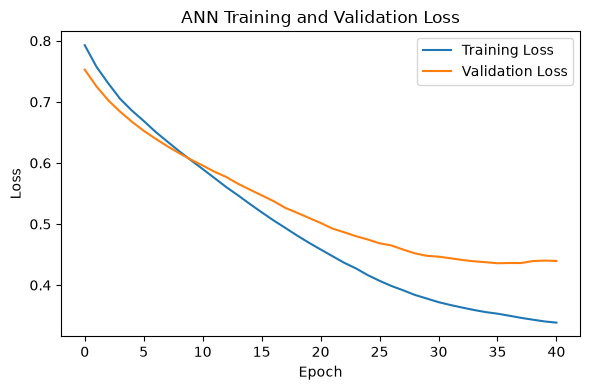

In [45]:
plt.figure(figsize=(6, 4))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ANN Training and Validation Loss")
plt.legend()

plt.tight_layout()
plt.savefig("../outputs/figures/ann_loss_curve.png", dpi=300)
plt.show()

**Interpretation:** 
- Use the generated training and validation loss curves to assess learning behaviour and possible overfitting.

In [46]:
# Save ANN training information
ann_training_info = pd.DataFrame({"item": ["random_seed", "batch_size", "maximum_epochs", "patience", "actual_epochs", "best_validation_loss"],
                                  "value": [42, 16, 50, 5, len(history.history["loss"]), min(history.history["val_loss"])]})

ann_training_info.to_csv("../outputs/ann_training_info.csv", index=False)
ann_training_info


,item,value
0,random_seed,42.000000
1,batch_size,16.000000
2,maximum_epochs,50.000000
3,patience,5.000000
4,actual_epochs,41.000000
5,best_validation_loss,0.435816


**Interpretation:**

- Training and validation loss are compared to check the learning behaviour of the ANN.
- If validation loss starts increasing while training loss continues decreasing, this is a sign of overfitting.
- Early stopping restores the weights from the best validation-loss point.


## D3 — Comparison and Evidence

The ANN is evaluated on the same 60 test records using a threshold of 0.5.

Its accuracy, precision, recall and F1-score are compared with Logistic Regression.


In [47]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_test_proba_ann = ann_model.predict(X_test_final, verbose=0).ravel()

y_test_pred_ann = (y_test_proba_ann >= 0.5).astype(int)

# ANN metrics
ann_accuracy = accuracy_score(y_test, y_test_pred_ann)
ann_precision = precision_score(y_test, y_test_pred_ann, zero_division=0)
ann_recall = recall_score(y_test, y_test_pred_ann, zero_division=0)
ann_f1 = f1_score(y_test, y_test_pred_ann, zero_division=0)

print("ANN Test Metrics : ")
print("Accuracy : ", ann_accuracy)
print("Precision : ", ann_precision)
print("Recall : ", ann_recall)
print("F1-score : ", ann_f1)

ANN Test Metrics : 
Accuracy :  0.8333333333333334
Precision :  0.88
Recall :  0.7586206896551724
F1-score :  0.8148148148148148


In [48]:
# Logistic Regression metrics
logreg_accuracy = accuracy_score(y_test, y_test_pred)
logreg_precision = precision_score(y_test, y_test_pred, zero_division=0)
logreg_recall = recall_score(y_test, y_test_pred, zero_division=0)
logreg_f1 = f1_score(y_test, y_test_pred, zero_division=0)

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "ANN"],
    "Accuracy": [logreg_accuracy, ann_accuracy],
    "Precision": [logreg_precision, ann_precision],
    "Recall": [logreg_recall, ann_recall],
    "F1-score": [logreg_f1, ann_f1]})

comparison

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.850000,0.884615,0.793103,0.836364
1,ANN,0.833333,0.880000,0.758621,0.814815


In [49]:
# Save final model comparison
comparison.to_csv("../outputs/final_model_comparison.csv", index=False)

# Save ANN predictions
ann_predictions = test[["record_id"]].copy()

ann_predictions["true_label"] = y_test.values
ann_predictions["predicted_label"] = y_test_pred_ann
ann_predictions["class_1_probability"] = y_test_proba_ann

ann_predictions.to_csv("../outputs/ann_test_predictions.csv", index=False)

print("Final comparison saved.")
print("ANN predictions saved.")

Final comparison saved.
ANN predictions saved.


In [50]:
# Saving trained ANN
ann_model.save("../models/ann_model.keras")

print("ANN model saved.")

ANN model saved.


### D3 Interpretation

The final model comparison should be based on the same untouched test records and the same 0.5 classification threshold.

F1-score is useful here because it combines precision and recall for the late class. The ANN does not need to outperform Logistic Regression; the comparison should be based on the observed holdout results and the simplicity of the models.


# Final Checks

The notebook now covers all five compulsory technical modules.

### Required evidence saved
- `outputs/splits.csv`
- `outputs/statistics_summary.csv`
- `outputs/inference_results.csv`
- `outputs/covariance_matrix.csv`
- `outputs/eigenvalues.csv`
- `outputs/preprocessing_audit.csv`
- `outputs/model_metrics.csv`
- `outputs/test_predictions.csv`
- `outputs/kmeans_diagnostics.csv`
- `outputs/cluster_profiles.csv`
- `outputs/final_model_comparison.csv`
- `outputs/ann_test_predictions.csv`
- `outputs/figures/traffic_histogram.png`
- `outputs/figures/confusion_matrix.png`
- `outputs/figures/kmeans_silhouette.png`
- `outputs/figures/ann_loss_curve.png`
- `models/preprocessing.joblib`
- `models/ann_model.keras`

The supplied raw CSV and `generate_data.py` are not modified.


In [51]:
# Final file check
from pathlib import Path

required_files = [
    "../outputs/splits.csv",
    "../outputs/statistics_summary.csv",
    "../outputs/inference_results.csv",
    "../outputs/covariance_matrix.csv",
    "../outputs/eigenvalues.csv",
    "../outputs/preprocessing_audit.csv",
    "../outputs/model_metrics.csv",
    "../outputs/test_predictions.csv",
    "../outputs/kmeans_diagnostics.csv",
    "../outputs/cluster_profiles.csv",
    "../outputs/final_model_comparison.csv",
    "../outputs/ann_test_predictions.csv",
    "../outputs/figures/traffic_histogram.png",
    "../outputs/figures/confusion_matrix.png",
    "../outputs/figures/kmeans_silhouette.png",
    "../outputs/figures/ann_loss_curve.png",
    "../models/preprocessing.joblib",
    "../models/ann_model.keras"
]

for file in required_files:
    print("✓" if Path(file).exists() else "○", file)

✓ ../outputs/splits.csv
✓ ../outputs/statistics_summary.csv
✓ ../outputs/inference_results.csv
✓ ../outputs/covariance_matrix.csv
✓ ../outputs/eigenvalues.csv
✓ ../outputs/preprocessing_audit.csv
✓ ../outputs/model_metrics.csv
✓ ../outputs/test_predictions.csv
✓ ../outputs/kmeans_diagnostics.csv
✓ ../outputs/cluster_profiles.csv
✓ ../outputs/final_model_comparison.csv
✓ ../outputs/ann_test_predictions.csv
✓ ../outputs/figures/traffic_histogram.png
✓ ../outputs/figures/confusion_matrix.png
✓ ../outputs/figures/kmeans_silhouette.png
✓ ../outputs/figures/ann_loss_curve.png
✓ ../models/preprocessing.joblib
✓ ../models/ann_model.keras


---